In [3]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../Tests/')
import plothelpers
import mesa_reader as mr

ModuleNotFoundError: No module named 'mesa_reader'

In [15]:
starList = [
#            './Fragos/12MsunProfileRG550R.data', 
#            './testedRGEvolution/12MsunProfileRG_V2.data', 
#            './Grichener/60MsunProfileRG_Z01.data', 
#            './Grichener/60MsunProfileRG_Z02.data', 
#            './RauModels/EarlyAGB_2.5MsunProfile.data',
#            './RauModels/RG_2.5MsunProfile.data'

]
starName = [
#            '12Msun', 
#            '12Msun Version 2', 
#            '60Msun Z = 0.01', 
#            '60Msun z = 0.02', 
#            'Early AGB 2.5Msun', 
#            'RG 2.5 Msun'
           ]

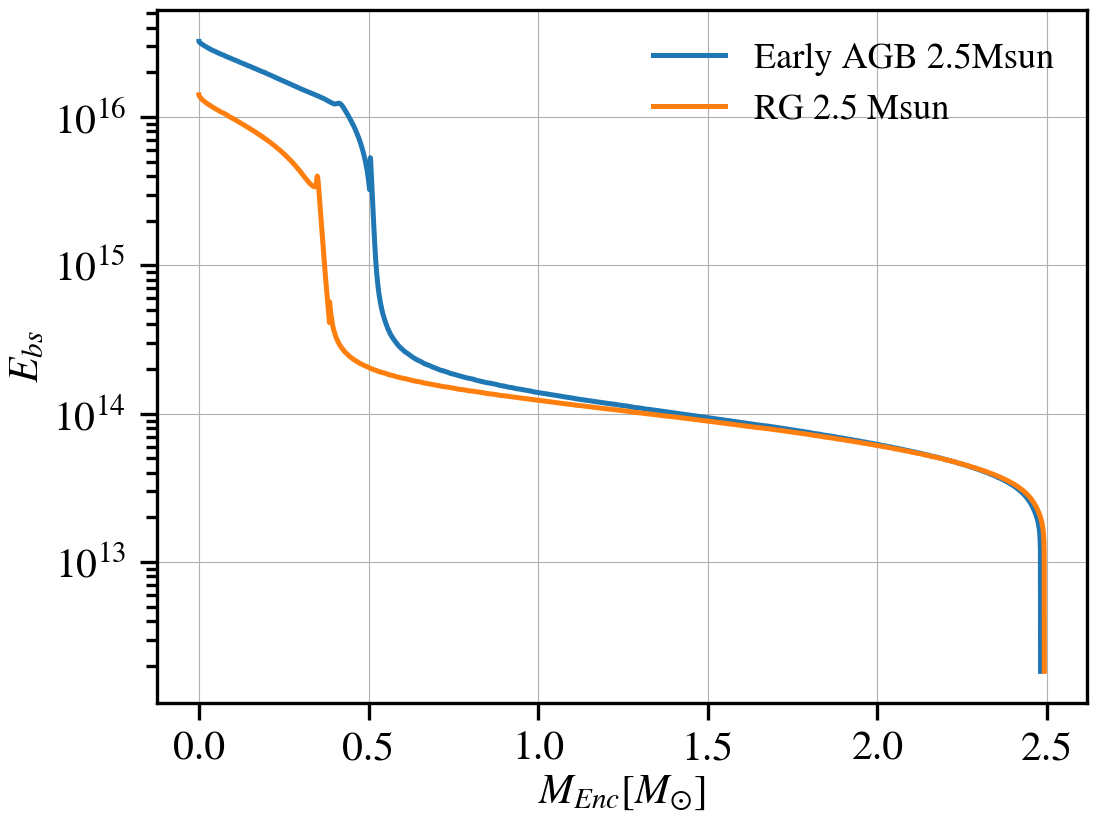

In [16]:
fig, ax = plt.subplots(facecolor='w')
ax.set(xlabel = '$ M_{Enc} [M_{\odot}]$',
       ylabel = r'$ E_{bs}$', 
       yscale = 'log'
      )

for a in range(0, len(starList)):
    star1 = mr.MesaData(starList[a])
    mGrav = star1.data('m_grav')
    Ebs = star1.data('energy')
    ax.plot(mGrav, np.abs(Ebs), label = starName[a])

ax.grid(True)
ax.legend(loc='best')

In [35]:
starList = [
            './APJL_798/12MsunProfileRG.data', 
#            './APJL_798/13MsunProfileRG.data', 
#            './APJL_798/14MsunProfileRG.data', 
#            './APJL_798/15MsunProfileRG.data', 
#            './APJL_798/16MsunProfileRG.data', 
#            './APJL_798/17MsunProfileRG.data', 
#            './APJL_798/18MsunProfileRG.data',
#            './APJL_798/20MsunProfileRG.data',
           ]
starName = [
            '12Msun RG', 
#            '13Msun RG', 
#            '14Msun RG', 
#            '15Msun RG', 
#            '16Msun RG', 
#            '17Msun RG', 
#            '18Msun RG',
#            '20Msun RG', 
           ]

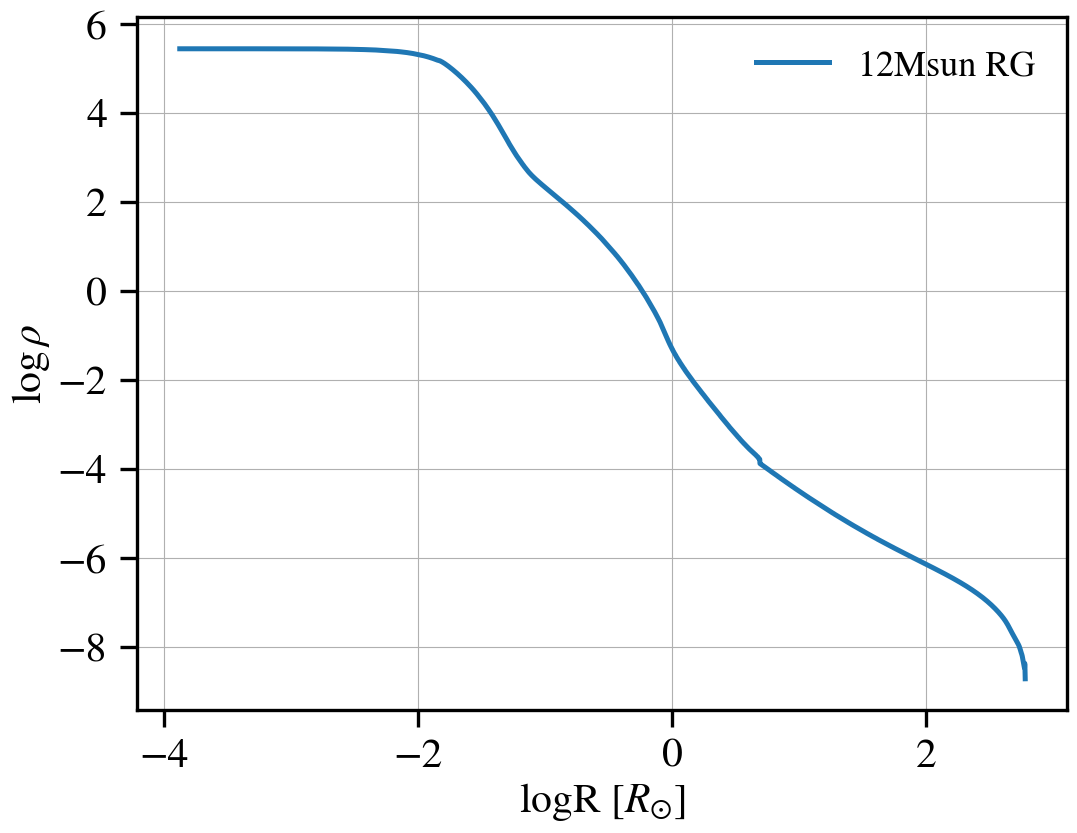

In [36]:
fig, ax = plt.subplots(facecolor='w')
ax.set(xlabel = 'logR $[R_{\odot}]$',
       ylabel = r'$\log \rho $', 
      )

for a in range(0, len(starList)):
    star1 = mr.MesaData(starList[a])
    logR1 = star1.data('logR')
    logRho1 = star1.data('logRho')
    ax.plot(logR1, logRho1, label = starName[a])
ax.grid(True)
ax.legend(loc='best')

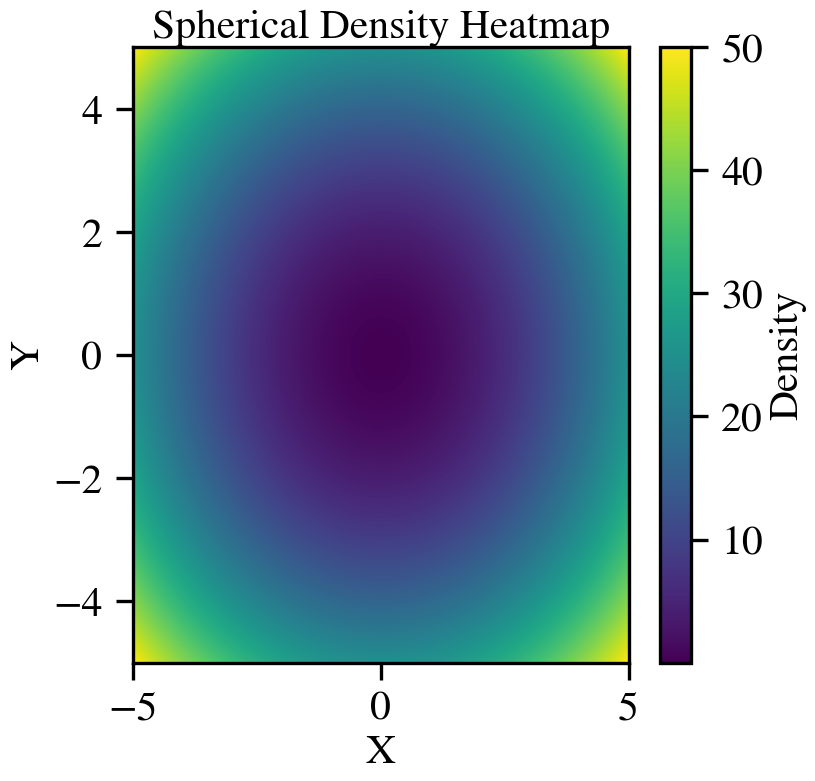

In [38]:
import numpy as np
import matplotlib.pyplot as plt

def create_spherical_density_heat_map(radius, density):
    """
    Create a 2D heatmap of a spherical density distribution.

    Parameters:
    - radius: 1D array of radii.

    Returns:
    - None (displays the plot).
    """
    # Create a meshgrid for the x and y coordinates
    x, y = np.meshgrid(np.linspace(-5, 5, len(radius)), 
                       np.linspace(-5, 5, len(radius)))

    # Convert Cartesian coordinates to polar coordinates
    rho = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)

    density = x**2+y**2

    # Generate density based on spherical coordinates
    #density = np.exp(-radius**2) * np.sin(phi)

    # Create a 2D heatmap
    fig, ax = plt.subplots(figsize=(8, 8))
    c = ax.pcolormesh(x, y, density, cmap='viridis', shading='auto')

    # Add a colorbar
    cbar = plt.colorbar(c)
    cbar.set_label('Density')

    # Set plot labels and title
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('Spherical Density Heatmap')

    plt.show()

# Example usage:
# Replace these arrays with your own values
#radius = np.linspace(0, 1, 100)
star1 = mr.MesaData('./ZAMS/12MsunProfile.data')
radius       = 10**star1.data('logR')[::-1]
density = 10**star1.data('logRho')[::-1]
create_spherical_density_heat_map(radius, density)